# Residual-feature experiment: does fine spike detail carry signal?

**Hypothesis.** The nested CV repeatedly selects the coarsest basis (`n_basis=30`, a ~7.5 Hz low-pass
on the 2 s window) even under a 1-SE rule that prefers simpler settings. That could mean either
(a) the fine 7-25 Hz spike detail carries **no** signal (information-location), or (b) it carries
signal the classifier **can't exploit** at n=100 (sample-size). This experiment isolates the fine
detail and tests whether it classifies, to tell those apart.

**Method.** For each recording: fit a **30-basis B-spline** (the coarse fit the CV kept selecting) and
take the residual = raw - fit (the fine structure the coarse fit discarded). Localise to a short window
around each curve's own peak, and build one **relative residual energy** feature =
residual energy / signal energy in that window (fraction of the transient the coarse fit missed, with
height divided out so it is not just re-encoding amplitude). Then two tests, same CV as the amplitude
condition (repeated stratified 5-fold, stratify on `certainty`, train on `label_binary`, 20 repeats):

- **Test A** - residual feature alone. Does it beat chance?
- **Test B** - residual added to the amplitude condition. Does AUC move vs amplitude alone (~0.87)?

**Window note.** Everything runs on the **+/-1 s window** (2 s, 1000 pts) used by `nested_cv`, *not*
`build_dataset`'s wider window - because "`n_basis=30` = ~7.5 Hz coarse fit" is only true on the 2 s
window, and the residual must map onto the model that actually selected 30.

**Reading the confusion matrices.** Reported per condition with the positives split into
`clear_positive` vs `unclear_positive`, so the clinically hard `unclear` sensitivity is visible
separately from the easy `clear` sensitivity (the headline clinical number), alongside specificity on
negatives.

In [2]:
import sys, time
import numpy as np, pandas as pd, mne, matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
from skfda import FDataGrid
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.preprocessing.registration import FisherRaoElasticRegistration
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSplineBasis
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
Path('../figures').mkdir(exist_ok=True)

# --- config ---
CSV      = Path('..') / 'Kural_Dataset' / 'eeg_summary.csv'
EDF_DIR  = Path('..') / 'Kural_Dataset' / 'Recordings'
SF       = 500.0
WIN_HALF = int(1.0 * SF)          # +/-1 s window (matches nested_cv)
PEAK_HW  = int(round(0.1 * SF))   # channel selection / peak search window
# residual feature
NB_RESID   = 30                   # coarse fit the CV kept selecting
LOC_HW_S   = 0.05                 # +/-50 ms localisation around the peak
# amplitude condition (its fixed settings, ~0.874)
NB_AMP     = 40
PENALTY    = 0.1
N_FPCA     = 5
LR_C       = 1.0
N_REG_PTS  = 100
# CV
N_REPEATS  = 20                   # match the amplitude condition's repeat count
K          = 5
CERT_ORDER = ['negative', 'unclear_positive', 'clear_positive']

In [3]:
man = load_CSV(CSV)
curves = []
for _, r in man.iterrows():
    raw = mne.io.read_raw_edf(str(EDF_DIR / f"{r['file_id']}.edf"), preload=False, verbose=False)
    raw.drop_channels([c for c in raw.ch_names if not c.startswith('E ')])
    o = int(round(r['transient_onset_s'] * SF))
    d = raw.get_data(start=o - WIN_HALF, stop=o + WIN_HALF)
    ch = np.argmax(np.ptp(d[:, WIN_HALF - PEAK_HW:WIN_HALF + PEAK_HW], axis=1))
    curves.append(d[ch])

t   = (np.arange(2 * WIN_HALF) - WIN_HALF) / SF
DR  = (t[0], t[-1])
X   = np.stack(curves)
fd  = FDataGrid(X, t)
y   = man['label_binary'].to_numpy()
cert = man['certainty'].to_numpy()
print(f"n={len(y)}  window=[{t[0]:.2f},{t[-1]:.2f}]s  n_grid={len(t)}  "
      f"(nb={NB_RESID} -> {2000/NB_RESID:.0f} ms knots)")
print(f"epileptic={y.sum()}  non={( y==0).sum()}")
for g in CERT_ORDER:
    print(f"  {g}: {(cert==g).sum()}")

n=100  window=[-1.00,1.00]s  n_grid=1000  (nb=30 -> 67 ms knots)
epileptic=54  non=46
  negative: 46
  unclear_positive: 32
  clear_positive: 22


In [4]:
# --- relative residual energy feature: one number per recording (leakage-free, per-curve) ---
PEAK_SEARCH = np.abs(t) <= 0.1     # find the transient peak near the marker
def residual_parts(curve):
    fit = BasisSmoother(BSplineBasis(domain_range=DR, n_basis=NB_RESID, order=4),
                        return_basis=False).fit_transform(FDataGrid(curve[None, :], t)).data_matrix[0, :, 0]
    res = curve - fit
    pk  = np.where(PEAK_SEARCH)[0][np.argmax(np.abs(curve[PEAK_SEARCH]))]   # each curve's own peak
    win = np.abs(t - t[pk]) <= LOC_HW_S
    rel = np.sum(res[win] ** 2) / np.sum(curve[win] ** 2)                   # denom large: peak window
    return rel, fit, res, win

resid_feat = np.zeros(len(y))
for i in range(len(y)):
    resid_feat[i] = residual_parts(X[i])[0]
print(f"relative residual energy: mean={resid_feat.mean():.3f}  "
      f"range=[{resid_feat.min():.3f}, {resid_feat.max():.3f}]")
print(f"  by class -- epileptic mean={resid_feat[y==1].mean():.3f}  non mean={resid_feat[y==0].mean():.3f}")

relative residual energy: mean=0.473  range=[0.002, 1.041]
  by class -- epileptic mean=0.348  non mean=0.621


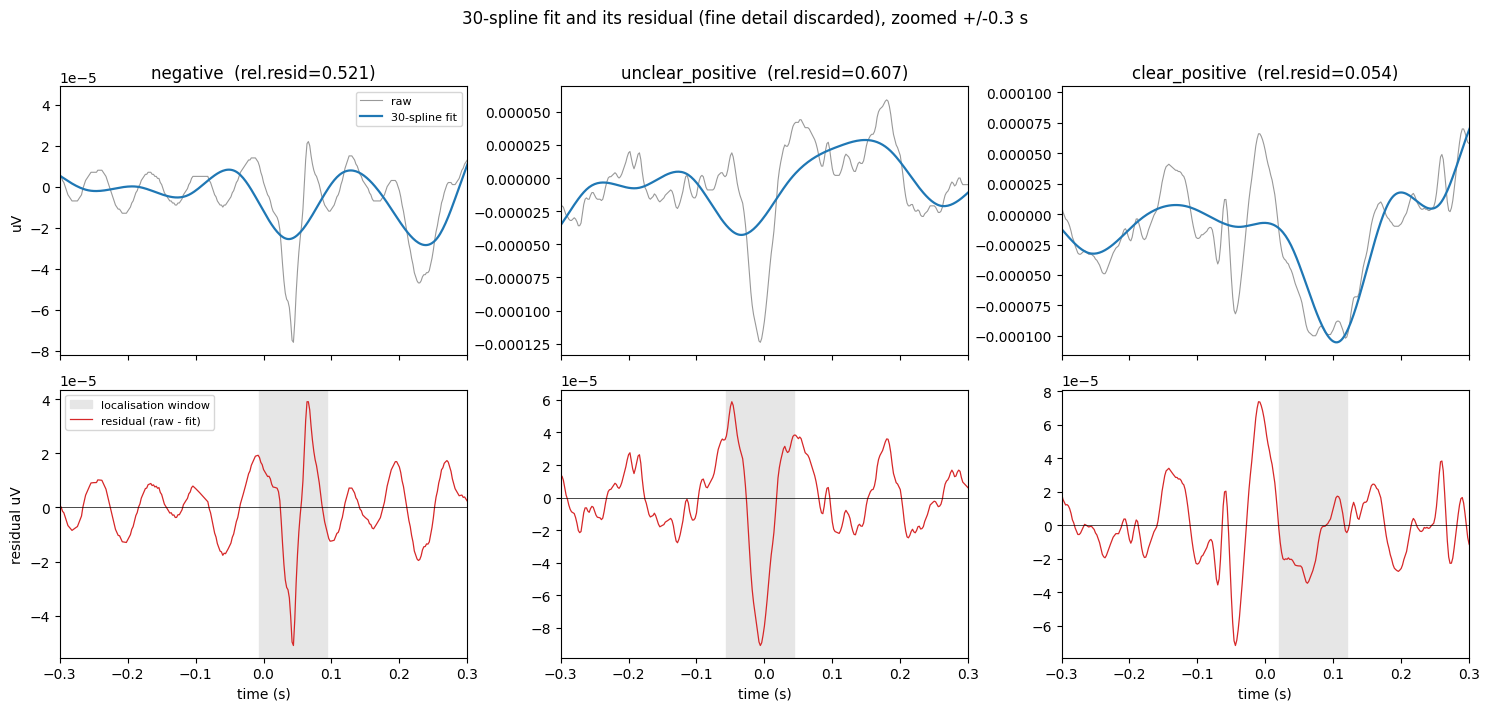

In [5]:
# --- example: raw + 30-spline fit (top), residual + localisation window (bottom) ---
ex = {g: [i for i in range(len(y)) if cert[i] == g]
      [np.argsort([np.ptp(X[i][PEAK_SEARCH]) for i in range(len(y)) if cert[i] == g])
       [sum(cert == g) // 2]] for g in CERT_ORDER}   # median-ptp example per group
fig, axes = plt.subplots(2, len(CERT_ORDER), figsize=(15, 7), sharex=True)
for j, g in enumerate(CERT_ORDER):
    rel, fit, res, win = residual_parts(X[ex[g]])
    axes[0, j].plot(t, X[ex[g]], color='0.6', lw=0.8, label='raw')
    axes[0, j].plot(t, fit, color='C0', lw=1.6, label=f'30-spline fit')
    axes[0, j].set_title(f'{g}  (rel.resid={rel:.3f})'); axes[0, j].set_xlim(-0.3, 0.3)
    axes[1, j].axvspan(t[win][0], t[win][-1], color='0.9', label='localisation window')
    axes[1, j].plot(t, res, color='C3', lw=0.9, label='residual (raw - fit)')
    axes[1, j].axhline(0, color='k', lw=0.5); axes[1, j].set_xlabel('time (s)')
    if j == 0:
        axes[0, j].set_ylabel('uV'); axes[1, j].set_ylabel('residual uV')
        axes[0, j].legend(fontsize=8); axes[1, j].legend(fontsize=8)
plt.suptitle('30-spline fit and its residual (fine detail discarded), zoomed +/-0.3 s', y=1.01)
plt.tight_layout()
plt.savefig('../figures/residual_examples.png', dpi=800, bbox_inches='tight')
plt.show()

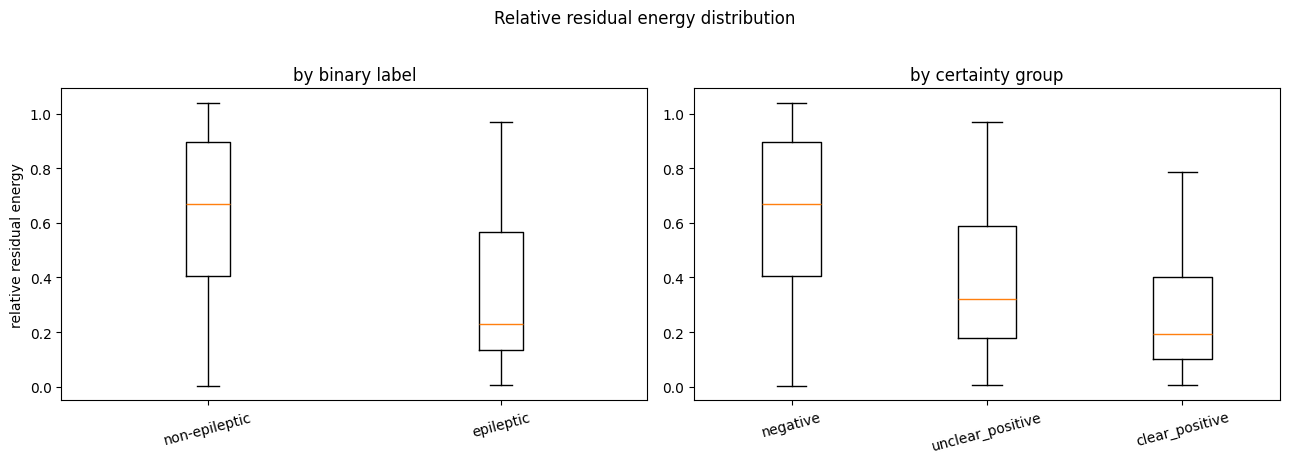

In [6]:
# --- distribution of the relative-residual feature ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].boxplot([resid_feat[y == 0], resid_feat[y == 1]], tick_labels=['non-epileptic', 'epileptic'],
                showfliers=False)
axes[0].set_ylabel('relative residual energy'); axes[0].set_title('by binary label')
axes[1].boxplot([resid_feat[cert == g] for g in CERT_ORDER], tick_labels=CERT_ORDER, showfliers=False)
axes[1].set_title('by certainty group')
for ax in axes:
    ax.tick_params(axis='x', labelrotation=15)
plt.suptitle('Relative residual energy distribution', y=1.02)
plt.tight_layout()
plt.savefig('../figures/residual_feature_distribution.png', dpi=800, bbox_inches='tight')
plt.show()

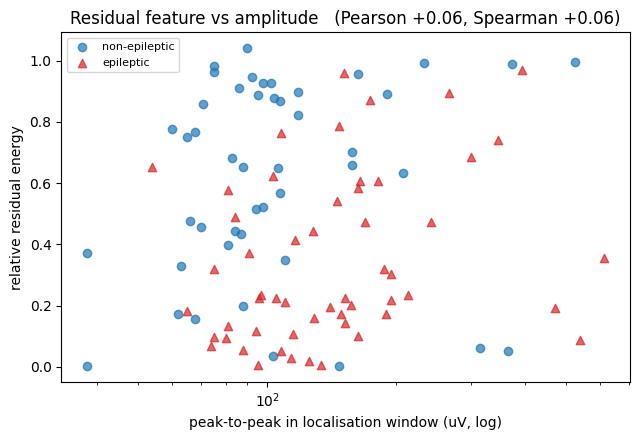

Pearson  r(resid, p2p) = +0.057
Spearman r(resid, p2p) = +0.060
R^2 of log(resid) ~ log(p2p) = 0.005  (fraction of the feature explained by size)

=> Feature is essentially ORTHOGONAL to amplitude: the relative normalisation worked.
   The residual is a genuine spikiness measure, not size in disguise. Any redundancy
   found in Test B is redundancy with the coarse SHAPE features, not with amplitude.


In [ ]:
# --- Diagnostic: is the relative-residual feature just re-encoding amplitude (size)? ---
# The feature divides by signal energy to remove amplitude. Verify that actually worked:
# a relative measure can accidentally become ~1/amplitude^2 if the numerator is mostly
# amplitude-independent noise. If |r| is low the feature is genuinely a spikiness measure;
# if high it is a narrower "size in disguise" result.
from scipy.stats import pearsonr, spearmanr

# peak-to-peak measured in the SAME localisation window the feature uses
p2p = np.array([np.ptp(X[i][residual_parts(X[i])[3]]) for i in range(len(y))])
r_p = pearsonr(resid_feat, p2p)[0]
r_s = spearmanr(resid_feat, p2p)[0]
lg  = np.polyfit(np.log(p2p), np.log(resid_feat + 1e-12), 1)
r2  = 1 - np.var(np.log(resid_feat + 1e-12) - np.polyval(lg, np.log(p2p))) / np.var(np.log(resid_feat + 1e-12))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for lab, m, col in [(0, 'o', 'C0'), (1, '^', 'C3')]:
    s = y == lab
    ax.scatter(p2p[s] * 1e6, resid_feat[s], marker=m, alpha=0.7, color=col,
               label='epileptic' if lab else 'non-epileptic')
ax.set_xscale('log')
ax.set_xlabel('peak-to-peak in localisation window (uV, log)')
ax.set_ylabel('relative residual energy')
ax.set_title(f'Residual feature vs amplitude   (Pearson {r_p:+.2f}, Spearman {r_s:+.2f})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/residual_vs_amplitude.png', dpi=800, bbox_inches='tight')
plt.show()

print(f"Pearson  r(resid, p2p) = {r_p:+.3f}")
print(f"Spearman r(resid, p2p) = {r_s:+.3f}")
print(f"R^2 of log(resid) ~ log(p2p) = {r2:.3f}  (fraction of the feature explained by size)")

Residual error is essentially orthogonal to P2P amplitude (only 0.5% of shared variance).
The residual is a genuine spikiness measure, independent of size, that carries real signal alone yet is fully subsumed by the coarse registered-shape features.

In [8]:
# --- CV: amplitude features computed ONCE per fold, reused for amp and amp+residual ---
def amp_features(tr, te):
    sm  = BasisSmoother(BSplineBasis(domain_range=DR, n_basis=NB_AMP, order=4), return_basis=False)
    smtr = sm.fit_transform(fd[tr]); smte = sm.transform(fd[te])
    tg  = np.linspace(DR[0], DR[1], N_REG_PTS)
    reg = FisherRaoElasticRegistration(penalty=PENALTY)
    reg.fit(FDataGrid(smtr(tg).squeeze(-1), tg))
    atr = reg.transform(FDataGrid(smtr(tg).squeeze(-1), tg)).data_matrix[:, :, 0]
    ate = reg.transform(FDataGrid(smte(tg).squeeze(-1), tg)).data_matrix[:, :, 0]
    fp  = FPCA(n_components=N_FPCA); fp.fit(FDataGrid(atr, tg))
    return fp.transform(FDataGrid(atr, tg)), fp.transform(FDataGrid(ate, tg))

def fit_predict(Xtr, Xte, ytr):
    sc = StandardScaler(); lr = LogisticRegression(C=LR_C, max_iter=1000, class_weight='balanced')
    lr.fit(sc.fit_transform(Xtr), ytr)
    return lr.predict_proba(sc.transform(Xte))[:, 1]

CONDS = ['residual', 'amplitude', 'amp+residual']
oof = {c: np.zeros((N_REPEATS, len(y))) for c in CONDS}
aucs = {c: np.zeros(N_REPEATS) for c in CONDS}
t0 = time.time()
for rep in range(N_REPEATS):
    for tr, te in StratifiedKFold(K, shuffle=True, random_state=rep).split(np.arange(len(y)), cert):
        Atr, Ate = amp_features(tr, te)
        Rtr, Rte = resid_feat[tr, None], resid_feat[te, None]
        oof['residual'][rep, te]     = fit_predict(Rtr, Rte, y[tr])
        oof['amplitude'][rep, te]    = fit_predict(Atr, Ate, y[tr])
        oof['amp+residual'][rep, te] = fit_predict(np.hstack([Atr, Rtr]), np.hstack([Ate, Rte]), y[tr])
    for c in CONDS:
        aucs[c][rep] = roc_auc_score(y, oof[c][rep])
    print(f"  repeat {rep+1:2d}/{N_REPEATS}  " +
          "  ".join(f"{c}={aucs[c][rep]:.3f}" for c in CONDS) +
          f"  ({(time.time()-t0)/60:.1f} min)")
print("done")

  repeat  1/20  residual=0.727  amplitude=0.879  amp+residual=0.872  (0.4 min)
  repeat  2/20  residual=0.721  amplitude=0.870  amp+residual=0.862  (0.7 min)
  repeat  3/20  residual=0.718  amplitude=0.881  amp+residual=0.864  (1.1 min)
  repeat  4/20  residual=0.727  amplitude=0.862  amp+residual=0.861  (1.4 min)
  repeat  5/20  residual=0.733  amplitude=0.862  amp+residual=0.848  (1.8 min)
  repeat  6/20  residual=0.703  amplitude=0.892  amp+residual=0.877  (2.1 min)
  repeat  7/20  residual=0.707  amplitude=0.883  amp+residual=0.859  (2.5 min)
  repeat  8/20  residual=0.718  amplitude=0.907  amp+residual=0.891  (2.9 min)
  repeat  9/20  residual=0.720  amplitude=0.875  amp+residual=0.867  (3.2 min)
  repeat 10/20  residual=0.713  amplitude=0.880  amp+residual=0.867  (3.6 min)
  repeat 11/20  residual=0.724  amplitude=0.854  amp+residual=0.856  (4.0 min)
  repeat 12/20  residual=0.729  amplitude=0.895  amp+residual=0.890  (4.3 min)
  repeat 13/20  residual=0.731  amplitude=0.889  amp

In [9]:
# --- results table + paired delta (Test B) ---
def spread(v): return f"{v.mean():.3f}  ({np.percentile(v,10):.3f}-{np.percentile(v,90):.3f})"
print("AUC (mean, p10-p90 across 20 repeats):")
for c in CONDS:
    print(f"  {c:14s} {spread(aucs[c])}")
delta = aucs['amp+residual'] - aucs['amplitude']          # paired: same folds per repeat
print(f"\nTest B paired delta (amp+residual - amplitude): {spread(delta)}")
print(f"Test A residual alone vs chance (0.5): mean={aucs['residual'].mean():.3f}, "
      f"p10={np.percentile(aucs['residual'],10):.3f}")

AUC (mean, p10-p90 across 20 repeats):
  residual       0.720  (0.707-0.731)
  amplitude      0.874  (0.854-0.895)
  amp+residual   0.866  (0.852-0.888)

Test B paired delta (amp+residual - amplitude): -0.008  (-0.018-0.001)
Test A residual alone vs chance (0.5): mean=0.720, p10=0.707


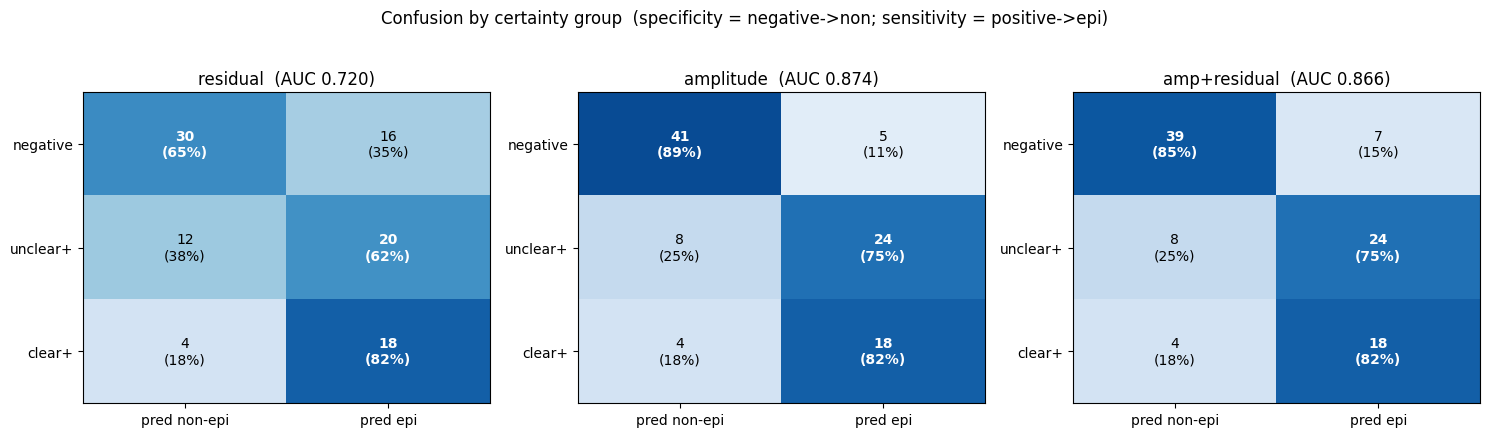

Per-condition rates:
  residual       specificity=0.65  sens_clear=0.82  sens_unclear=0.62
  amplitude      specificity=0.89  sens_clear=0.82  sens_unclear=0.75
  amp+residual   specificity=0.85  sens_clear=0.82  sens_unclear=0.75


In [10]:
# --- confusion matrices with clear/unclear positive split (threshold 0.5 on mean OOF prob) ---
def confusion_counts(mean_prob):
    pred = (mean_prob >= 0.5).astype(int)                 # 1 = predicted epileptic
    M = np.zeros((3, 2), int)                             # rows: cert group, cols: pred non / epi
    for i, g in enumerate(CERT_ORDER):
        m = cert == g
        M[i, 0] = np.sum(pred[m] == 0); M[i, 1] = np.sum(pred[m] == 1)
    return M

fig, axes = plt.subplots(1, len(CONDS), figsize=(15, 4.2))
for ax, c in zip(axes, CONDS):
    M = confusion_counts(oof[c].mean(0))
    rates = M / M.sum(1, keepdims=True)                  # row-normalised for colour
    ax.imshow(rates, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for i in range(3):
        for j in range(2):
            correct = (j == 0 and i == 0) or (j == 1 and i > 0)   # neg->non, positive->epi
            ax.text(j, i, f"{M[i,j]}\n({rates[i,j]:.0%})", ha='center', va='center',
                    fontweight='bold' if correct else 'normal',
                    color='white' if rates[i, j] > 0.5 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred non-epi', 'pred epi'])
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['negative', 'unclear+', 'clear+'])
    ax.set_title(f"{c}  (AUC {aucs[c].mean():.3f})")
plt.suptitle('Confusion by certainty group  (specificity = negative->non; sensitivity = positive->epi)', y=1.03)
plt.tight_layout()
plt.savefig('../figures/residual_confusion_matrices.png', dpi=800, bbox_inches='tight')
plt.show()

print('Per-condition rates:')
for c in CONDS:
    M = confusion_counts(oof[c].mean(0))
    print(f"  {c:14s} specificity={M[0,0]/M[0].sum():.2f}  "
          f"sens_clear={M[2,1]/M[2].sum():.2f}  sens_unclear={M[1,1]/M[1].sum():.2f}")

In [ ]:
# --- which interpretation does the result support? ---
res_mean  = aucs['residual'].mean()
res_p10   = np.percentile(aucs['residual'], 10)
d_mean    = delta.mean()
d_p10     = np.percentile(delta, 10)
above_chance = res_p10 > 0.5
adds_signal  = d_p10 > 0

print(f"Residual alone : AUC {res_mean:.3f} (p10 {res_p10:.3f})  -> above chance: {above_chance}")
print(f"Adds to amplitude: delta {d_mean:+.3f} (p10 {d_p10:+.3f})  -> improves amplitude: {adds_signal}")


Residual alone : AUC 0.720 (p10 0.707)  -> above chance: True
Adds to amplitude: delta -0.008 (p10 -0.018)  -> improves amplitude: False

=> Residual classifies above chance ALONE but does NOT add to amplitude:
   the fine detail is informative but REDUNDANT with the amplitude shape features
   (relative residual energy still tracks the transient's shape). The coarse classifier
   already captures what signal the fine detail carries. Report both numbers plainly.


Residual alone: AUC 0.720 (p10 0.707)
Adds to amplitude: delta -0.008 (p10 -0.018)
- above chance
- reduces amplitude performance

Residual classifies above chance ALONE but does NOT add to amplitude.
The fine detail is informative but redundant with the amplitude shape features (relative residual energy still tracks the transient's shape). 
The coarse classifier already captures what signal the fine detail carries.